# General notebook

In [21]:
using Revise
Revise.retry() # Just in case if only Revise is not sufficient. 
include("lattice_protein.jl")

Imports done, importing hamiltonian path
hamiltonian path imported, importing metropolis
metropolis imported, importing benchmark
benchmark imported, importing visualization
visualization imported, importing tree
tree imported, importing lattice_protein


## Hamiltonian paths

In [3]:
println("We find $(length(PATHS)) unique paths.")
println(first(PATHS))

We find 103346 unique paths.
Int8[1, 2, 3, 6, 5, 4, 7, 8, 9, 18, 17, 16, 13, 14, 15, 12, 11, 10, 19, 20, 21, 24, 23, 22, 25, 26, 27]


Contact map for the first path:
Path visualization for the 75005:


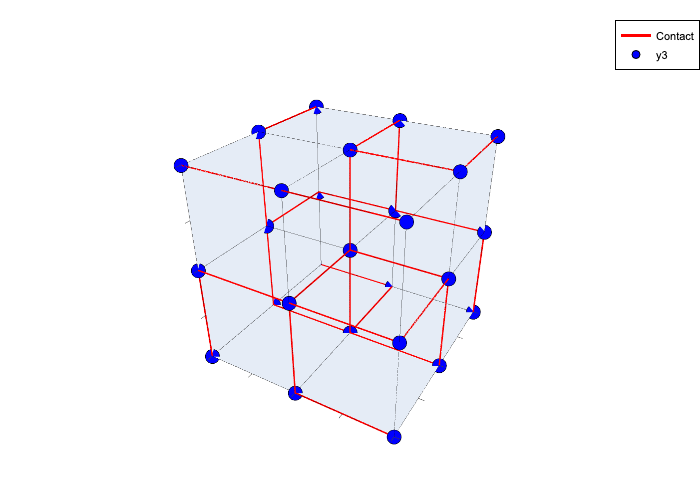

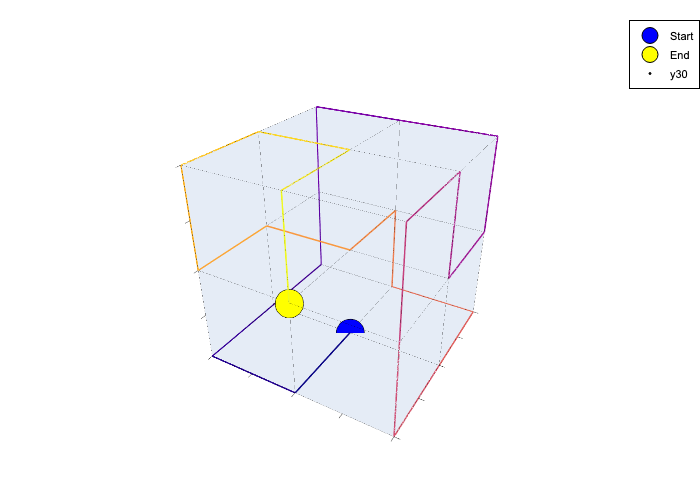

In [4]:
println("Contact map for the first path:")
liste_contact = contact_map(PATHS[75005])
display(plot_cube_ctc_map(x, y, z, lx, ly, lz, liste_contact))

println("Path visualization for the 75005:")
display(plot_cube_path(x, y, z, lx, ly, lz, PATHS[75005]))

## Metropolis general results

Attention : si on veut changer de matrice (MJ*5 ou MJ_1996) il faut restart le kernel et modifier la ligne const dans le ficher metropolis.jl. 

MJ*5

algo (β=100) 100%|███████████████████████████████████████| Time: 0:01:12


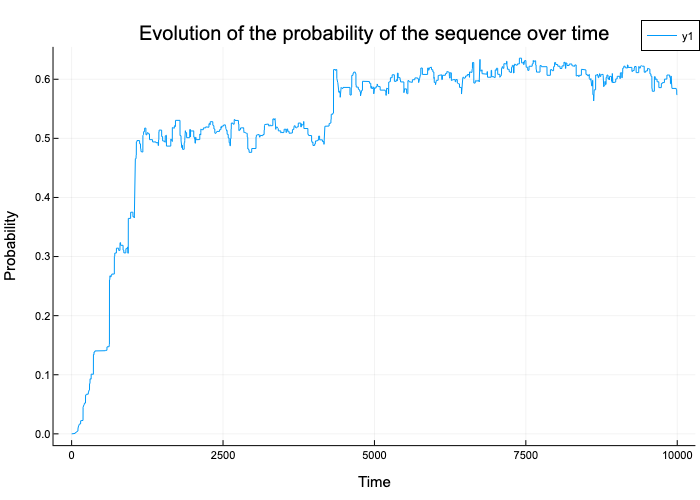

In [5]:
# with all the data
seq = generate_seq()
print(matrix_name)
target_number = 75005
all_ctc_maps = all_contact_maps(PATHS)
plot_probability(seq, target_number, all_ctc_maps, 10000)

MJ*5

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:06


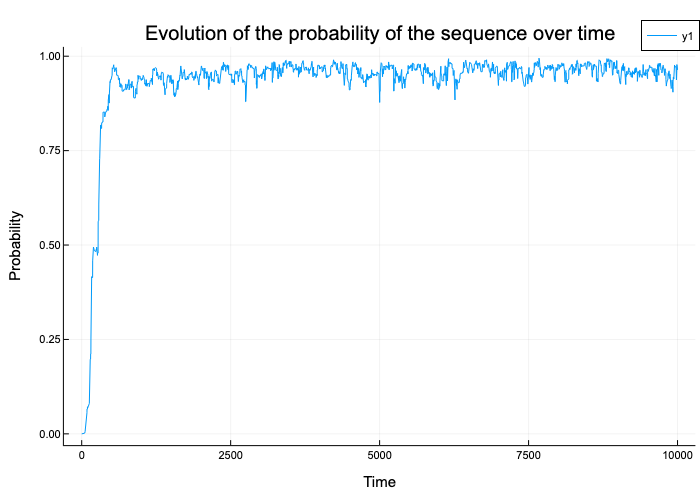

In [6]:
# with few data
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
print(matrix_name)

all_ctc_maps = all_contact_maps(paths_reduced)
plot_probability(seq, target_number, all_ctc_maps, 10000)

Testing beta = 10


algo (β=10) 100%|████████████████████████████████████████| Time: 0:00:02


Testing beta = 50


algo (β=50) 100%|████████████████████████████████████████| Time: 0:00:02


Testing beta = 100


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:02


Testing beta = 1000


algo (β=1000) 100%|██████████████████████████████████████| Time: 0:00:02


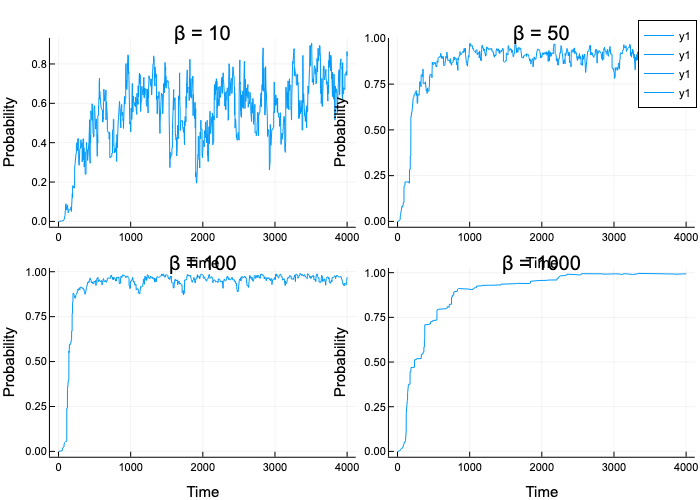

Dict{Float64, Tuple{Vector{Int64}, Vector{Float64}}} with 4 entries:
  50.0   => ([13, 15, 16, 19, 19, 4, 9, 15, 14, 20  …  16, 16, 5, 9, 3, 9, 5, 5…
  10.0   => ([4, 13, 4, 19, 19, 15, 15, 1, 3, 9  …  5, 6, 19, 14, 15, 6, 15, 19…
  1000.0 => ([8, 15, 3, 1, 18, 15, 1, 16, 15, 19  …  18, 14, 19, 15, 5, 16, 15,…
  100.0  => ([18, 7, 12, 16, 3, 11, 16, 2, 3, 16  …  2, 17, 15, 19, 1, 19, 1, 1…

In [7]:
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)


benchmark_beta()

## Further observations

### Chain evolution

ici

Multi-init 100%|█████████████████████████████████████████| Time: 0:00:21


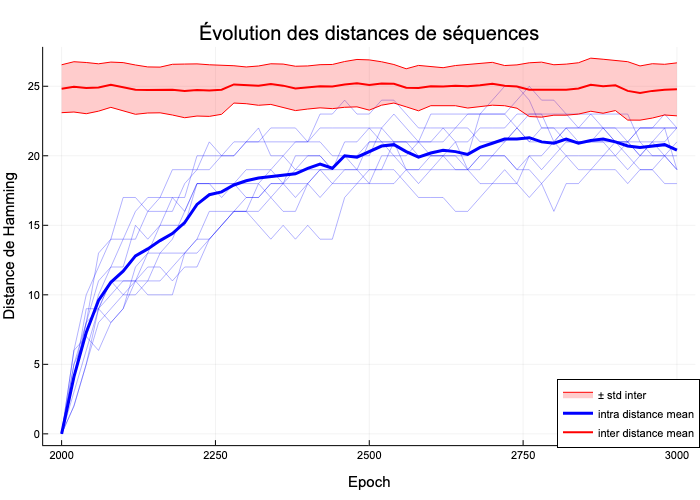

In [8]:
paths_reduced = reduce_data(PATHS, 10)
beta = 100.0

seq_over_time = multi_init_seq_over_time(target_number, all_ctc_maps, epochs=3000, beta=beta, threshold=2000, step=20, runs=10)
plot_distances_inter_intra(seq_over_time, beta=beta)

### All proba

In [9]:
final_seq, p_struct_time_t, p_final,_=algo_show_probability_distribution(seq, target_number, all_ctc_maps, 10000, 100)
show_sorted_indices(p_final)

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:06


structure 1234 : 0.9548307250200334
structure 3118 : 0.011722781360964267
structure 1233 : 0.005821360943414691
structure 1797 : 0.004312570256046527
structure 2763 : 0.002366788737991296
structure 3122 : 0.0013655183135947502
structure 3085 : 0.0013655183135947416
structure 529 : 0.0009153342988313539
structure 3103 : 0.0009153342988313455
structure 5072 : 0.0007494123398003027
structure 8083 : 0.0007128630687019777
structure 3083 : 0.0006780963265891687
structure 5179 : 0.0006450251784974858
structure 7660 : 0.0006450251784974852
structure 7762 : 0.000555178316127779
structure 3084 : 0.0005551783161277781
structure 7760 : 0.0005551783161277774
structure 1558 : 0.0005023461141146221
structure 3178 : 0.00043237330734457715
structure 7640 : 0.00043237330734457275


In [10]:
# Mutations en fonction de la position
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234

all_ctc_maps = all_contact_maps(paths_reduced)

beta = 100

_, _, saved_seq = algo(seq, target_number, all_ctc_maps, 10000, beta, 2000, 200)
println("On a sauvegardé $(length(saved_seq)) structures.")

n_mutations_per_position = amount_of_mutations(saved_seq)
n_mutations_per_position


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:06


On a sauvegardé 41 structures.


Dict{Int64, Int64} with 27 entries:
  5  => 32
  16 => 24
  20 => 14
  12 => 28
  24 => 28
  8  => 27
  17 => 22
  1  => 38
  23 => 15
  22 => 30
  19 => 22
  6  => 32
  11 => 22
  9  => 10
  14 => 28
  3  => 31
  7  => 10
  25 => 21
  4  => 15
  ⋮  => ⋮

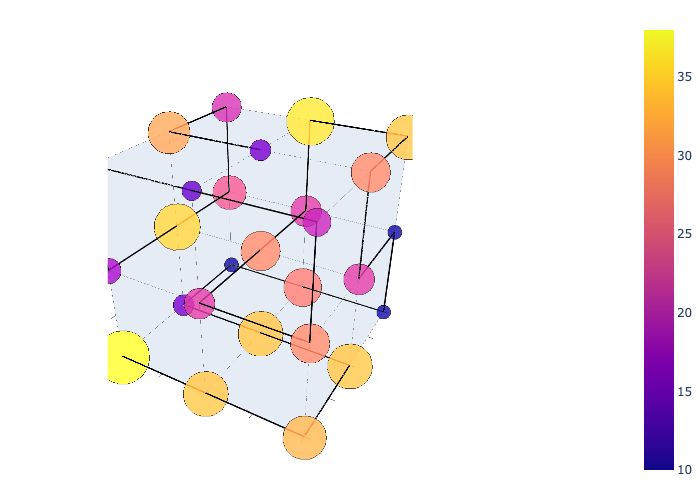

In [22]:
plot_cube_with_mutations_on_sphere(x, y, z, lx, ly, lz, PATHS[1234], n_mutations_per_position)

## Tree generation

In [12]:
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)

root,_,_ = algo(seq, target_number, all_ctc_maps, 5000, 100, 10000, 200, true)
newick, seq_dict = create_genealogy(root, 50, 2, target_number, all_ctc_maps)

println(newick)

# Charger l'arbre dans TreeTools
tree = parse_newick_string(newick)

for node in nodes(tree)
    name = label(node)
    println("$name : $(seq_dict[name])")
end

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:03


((N3:50,N4:50)N2:50,(N6:50,N7:50)N5:50)N1;
N3 : [13, 18, 5, 16, 13, 13, 19, 10, 15, 16, 2, 2, 5, 7, 18, 5, 16, 19, 17, 14, 20, 3, 14, 15, 5, 19, 18]
N4 : [3, 18, 2, 16, 16, 12, 18, 9, 15, 16, 2, 2, 5, 7, 18, 1, 16, 19, 17, 16, 10, 3, 16, 15, 2, 19, 18]
N5 : [8, 14, 5, 16, 13, 13, 19, 20, 15, 16, 2, 3, 5, 7, 18, 7, 16, 19, 19, 18, 9, 3, 15, 15, 2, 19, 3]
N7 : [19, 14, 9, 16, 13, 15, 19, 18, 15, 16, 2, 3, 5, 7, 18, 7, 16, 19, 19, 18, 9, 3, 15, 15, 2, 19, 3]
N1 : [17, 14, 5, 16, 13, 13, 19, 20, 15, 16, 2, 3, 5, 7, 18, 7, 16, 19, 19, 14, 11, 6, 20, 15, 2, 19, 17]
N6 : [8, 1, 3, 16, 13, 13, 19, 20, 15, 16, 2, 3, 5, 7, 18, 7, 16, 19, 19, 18, 9, 2, 15, 15, 7, 19, 18]
N2 : [13, 18, 7, 16, 13, 12, 19, 20, 15, 16, 2, 2, 5, 7, 18, 8, 16, 19, 17, 14, 11, 3, 16, 15, 2, 19, 18]


In [13]:
simple_print_distance_matrix(seq_dict)

     N3    N4    N5    N7    N1    N6    N2    
N3   0     11    11    13    11    12    7     
N4   11    0     14    14    15    15    8     
N5   11    14    0     4     6     5     11    
N7   13    14    4     0     9     8     12    
N1   11    15    6     9     0     9     10    
N6   12    15    5     8     9     0     12    
N2   7     8     11    12    10    12    0     


In [14]:
p = plot_distance_matrix(seq_dict)
savefig(p, "../figures/distance_matrix.svg")

"/Users/marie.gabilly/Documents/master/m1/s2/projet/figures/distance_matrix.svg"

In [15]:
tree


                                        _____________________________________ N3
  _____________________________________|
 |                                     |_____________________________________ N4
_|
 |                                      _____________________________________ N6
 |_____________________________________|
                                       |_____________________________________ N7
